# Notebook 03: Análisis Exploratorio de Datos (EDA)

## Objetivo
Explorar el dataset limpio de TAWOS para comprender la distribución de las variables objetivo,
identificar correlaciones entre features y justificar las decisiones de modelado.
Los gráficos generados sirven de soporte visual para la memoria del TFG (Sección 6.3.1).

In [25]:
# 1. IMPORTACIONES Y CONFIGURACIÓN VISUAL
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Ocultar avisos de librerías para mantener el cuaderno limpio

# Configuración de estilo profesional para el TFG (Memoria)
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12, 
    'figure.figsize': (10, 6),
    'axes.titlepad': 15,
    'axes.titleweight': 'bold'
})
colores_target = ['#2ECC71', '#E74C3C'] # Verde (A tiempo/Seguro) y Rojo (Retraso/Riesgo)

# Carga del Dataset Limpio
df = pd.read_csv('../data/processed/dataset_entrenamiento_tawos.csv')
print(f"✅ Dataset cargado correctamente: {df.shape[0]} tareas listas para análisis exploratorio.")
display(df.head(3))

✅ Dataset cargado correctamente: 142151 tareas listas para análisis exploratorio.


,Issue_Key,Issue_Type,Project_ID,Project_Name,Sprint_ID,Sprint_State,Story_Point,Total_Effort_Minutes,In_Progress_Minutes,Resolution_Time_Minutes,Title_Changed_After_Estimation,Description_Changed_After_Estimation,Story_Point_Changed_After_Estimation,Blocker_Count,Target_Retraso,Target_Riesgo
0,XD-3748,Bug,1,Spring XD,-1,UNASSIGNED,1.0,428822.0,87.0,436558.0,0,0,0,0,0,1
1,XD-3747,Enhancement,1,Spring XD,-1,UNASSIGNED,1.0,336752.0,2.0,437537.0,1,0,0,0,0,1
2,XD-3744,Enhancement,1,Spring XD,1,CLOSED,1.0,172.0,13.0,194.0,0,0,0,0,0,0


## 1. Distribución de las variables objetivo
Analizamos el balance de clases para `Target_Retraso` y `Target_Riesgo`.
Un desbalanceo significativo condicionará la estrategia de ponderación de clases durante el entrenamiento.

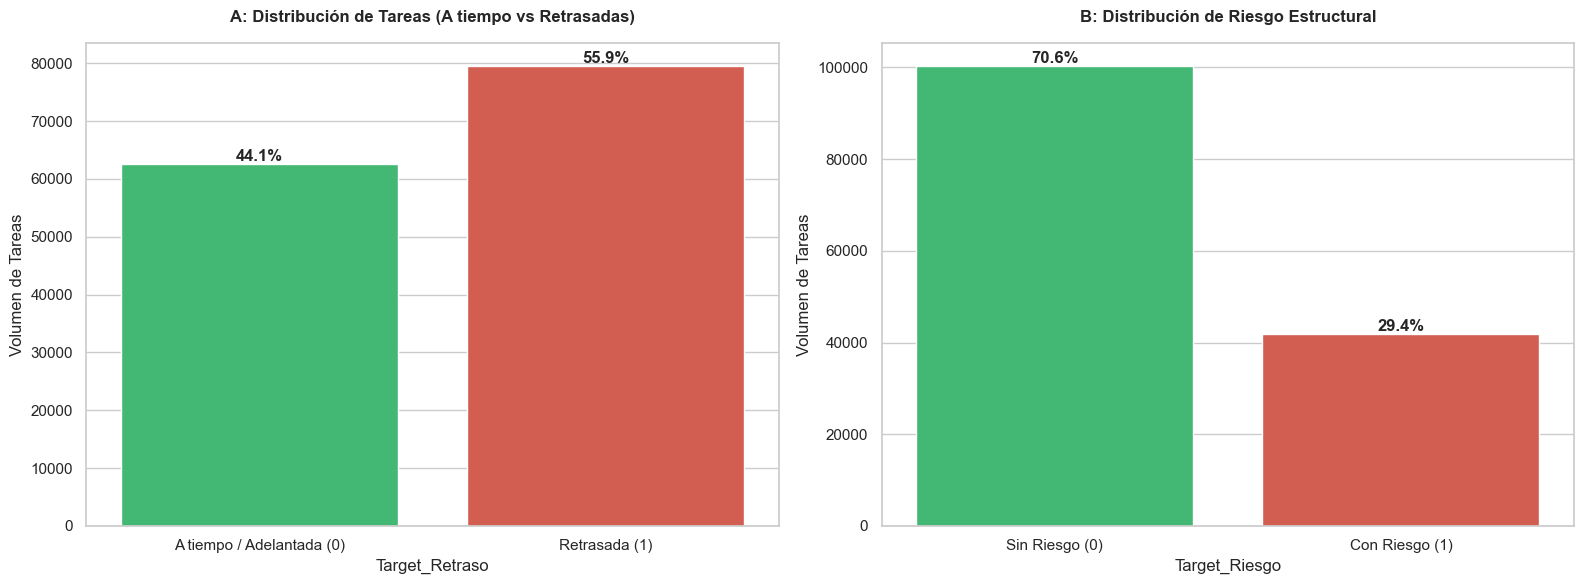

In [26]:
# 2. ANÁLISIS DE DISTRIBUCIÓN DE CLASES (EL PROBLEMA EMPÍRICO)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Retrasos
ax1 = sns.countplot(data=df, x='Target_Retraso', hue='Target_Retraso', palette=colores_target, legend=False, ax=axes[0])
axes[0].set_title('A: Distribución de Tareas (A tiempo vs Retrasadas)')
axes[0].set_xticklabels(['A tiempo / Adelantada (0)', 'Retrasada (1)'])
axes[0].set_ylabel('Volumen de Tareas')

# Etiquetas Gráfico A
total1 = len(df)
for p in ax1.patches:
    porcentaje = f'{100 * p.get_height() / total1:.1f}%'
    ax1.annotate(porcentaje, (p.get_x() + p.get_width() / 2, p.get_height()), #coloca el texto de la barra
                 ha='center', va='bottom', fontweight='bold', fontsize=12)

# Gráfico B: Riesgos
ax2 = sns.countplot(data=df, x='Target_Riesgo', hue='Target_Riesgo', palette=colores_target, legend=False, ax=axes[1])
axes[1].set_title('B: Distribución de Riesgo Estructural')
axes[1].set_xticklabels(['Sin Riesgo (0)', 'Con Riesgo (1)'])
axes[1].set_ylabel('Volumen de Tareas')

# Etiquetas Gráfico B
for p in ax2.patches:
    porcentaje = f'{100 * p.get_height() / total1:.1f}%'
    ax2.annotate(porcentaje, (p.get_x() + p.get_width() / 2, p.get_height()), 
                 ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
# Descomenta la siguiente línea si quieres que la imagen se guarde sola en tu disco duro
# plt.savefig('../data/figures/distribucion_targets.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Matriz de correlación
Mapa de calor con las correlaciones de Pearson entre las variables numéricas principales.
Permite detectar colinearidades (ej. Story_Point vs Total_Effort_Minutes) y evaluar qué features
tienen mayor relación lineal con los targets.

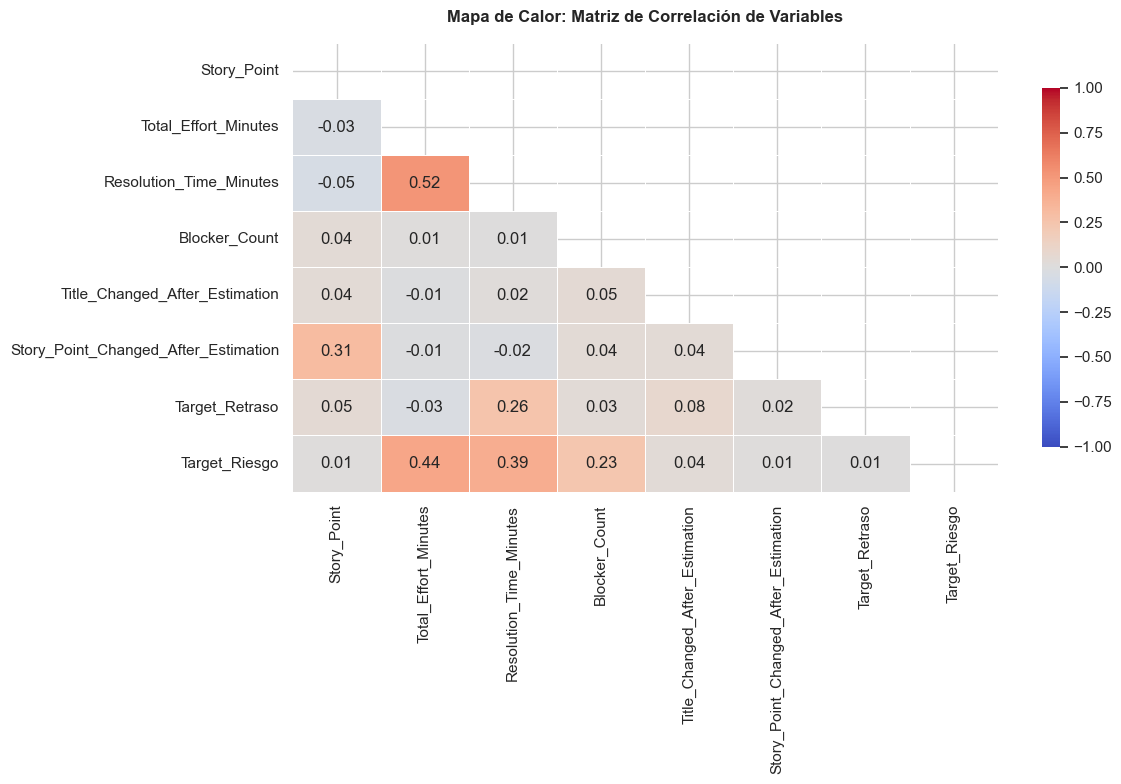

In [27]:
# 3. MATRIZ DE CORRELACIÓN (¿Qué influye en los retrasos y riesgos?)
cols_correlacion = [
    'Story_Point', 'Total_Effort_Minutes', 'Resolution_Time_Minutes', 
    'Blocker_Count', 'Title_Changed_After_Estimation', 
    'Story_Point_Changed_After_Estimation', 
    'Target_Retraso', 'Target_Riesgo'
]

plt.figure(figsize=(12, 8))
matriz_corr = df[cols_correlacion].corr() #coeficiente correlación pearson

# Crear máscara para ocultar el triángulo superior (hace que el gráfico sea más elegante y limpio)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

sns.heatmap(matriz_corr, annot=True, mask=mask, cmap='coolwarm', fmt=".2f",  
            linewidths=0.5, vmin=-1, vmax=1, cbar_kws={"shrink": .8}) #creación mapa de calor

plt.title('Mapa de Calor: Matriz de Correlación de Variables')
plt.tight_layout()
# plt.savefig('../data/figures/matriz_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Impacto de los bloqueos en el retraso
Analizamos cómo la cantidad de bloqueos activos (`Blocker_Count`) afecta a la probabilidad de retraso.
Esta relación es clave para la definición de `Target_Riesgo` y para las recomendaciones del LLM.

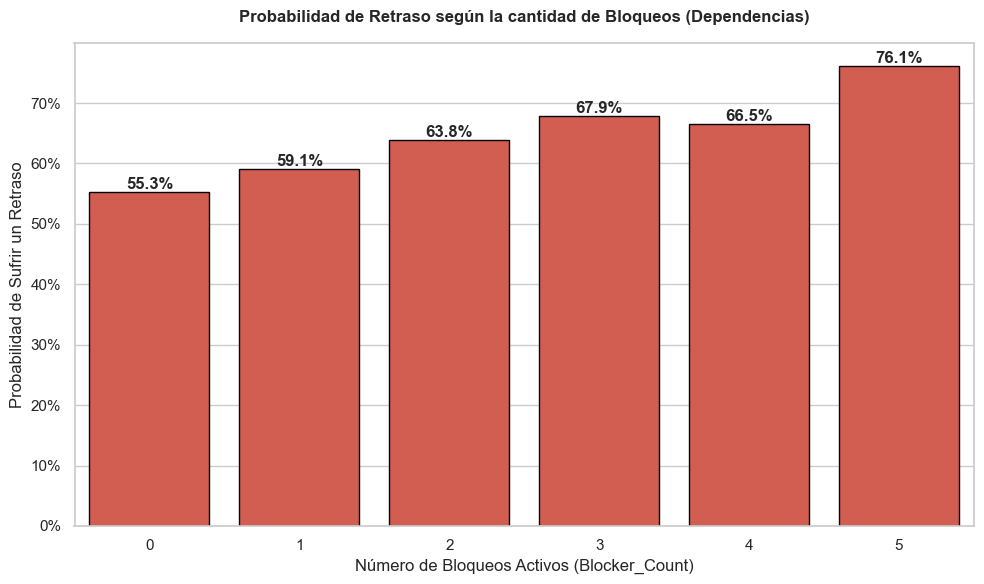

In [28]:
# 4. IMPACTO DE LOS BLOQUEOS EN EL RETRASO
plt.figure(figsize=(10, 6))

# Filtramos para no ver valores extremos (>5 bloqueos) y hacer el gráfico representativo
df_bloqueos = df[df['Blocker_Count'] <= 5]

ax = sns.barplot(data=df_bloqueos, x='Blocker_Count', y='Target_Retraso', 
                 color='#E74C3C', errorbar=None, edgecolor='black')

plt.title('Probabilidad de Retraso según la cantidad de Bloqueos (Dependencias)')
plt.xlabel('Número de Bloqueos Activos (Blocker_Count)')
plt.ylabel('Probabilidad de Sufrir un Retraso')

# Formatear eje Y como porcentaje
from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1))

# Añadir etiquetas de porcentaje encima de las barras
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%", 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontweight='bold') 
plt.tight_layout()
# plt.savefig('../data/figures/impacto_bloqueos.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Distribución por tipo de tarea
Analizamos qué tipos de tarea predominan en el dataset y su frecuencia relativa.
Esta distribución condiciona la capacidad del modelo para aprender patrones en categorías minoritarias.

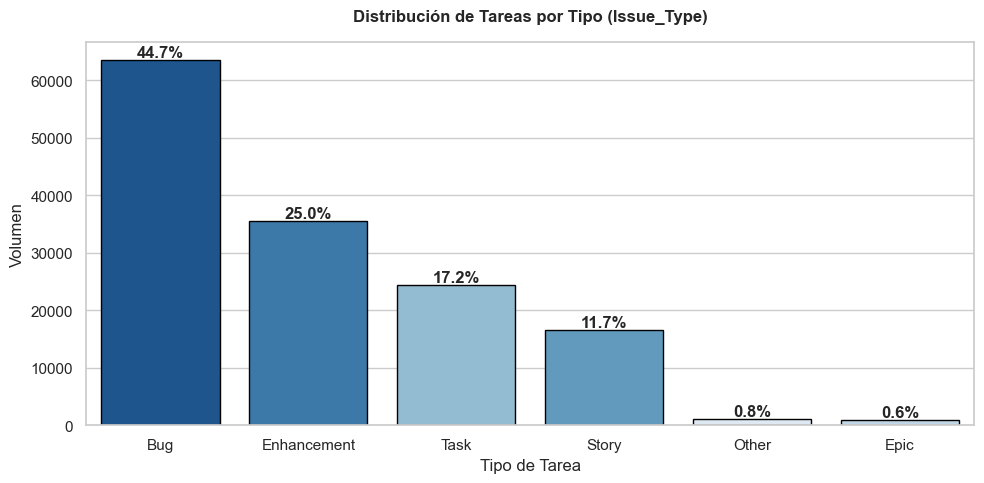

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
order = df['Issue_Type'].value_counts().index
ax = sns.countplot(data=df, x='Issue_Type', order=order, hue='Issue_Type', palette='Blues_r', legend=False, edgecolor='black')
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / len(df):.1f}%'
    ax.annotate(porcentaje, (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.title('Distribución de Tareas por Tipo (Issue_Type)')
plt.xlabel('Tipo de Tarea')
plt.ylabel('Volumen')
plt.tight_layout()
# plt.savefig('../data/figures/distribucion_issue_type.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Distribución de variables de estimación
Inspeccionamos la distribución de los Story Points y el esfuerzo total estimado.
Colas pesadas y asimetrías son esperables en datos de gestión ágil y justifican
el uso de StandardScaler durante el preprocesamiento.

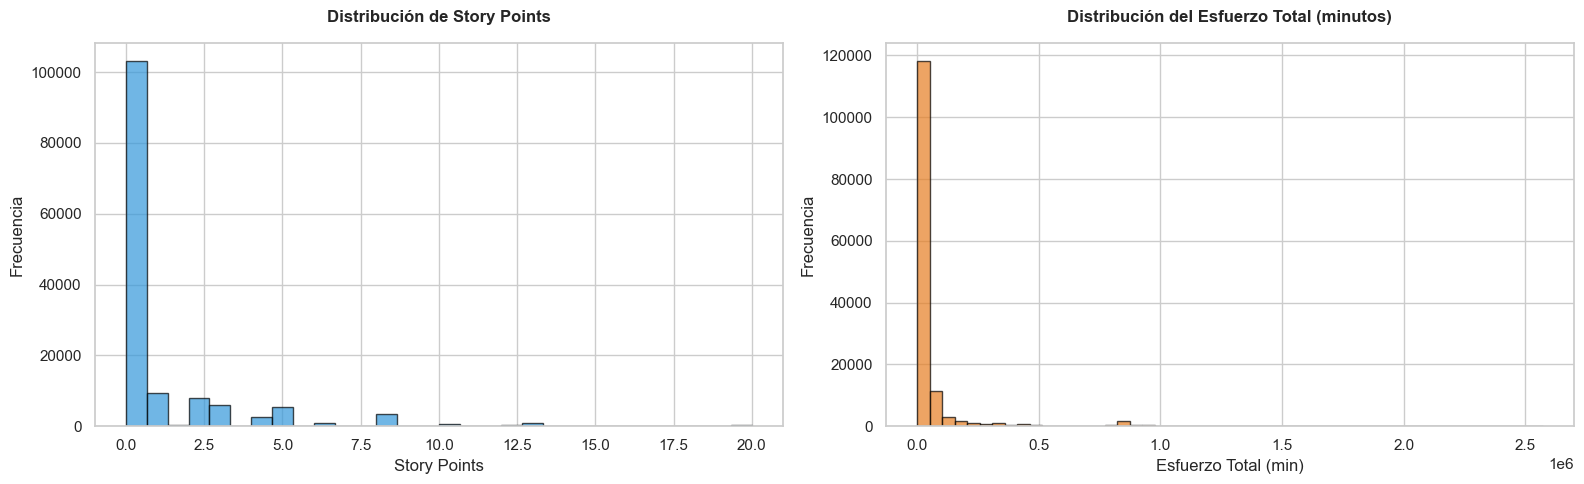

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Story Points
axes[0].hist(df['Story_Point'], bins=30, color='#3498DB', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de Story Points')
axes[0].set_xlabel('Story Points')
axes[0].set_ylabel('Frecuencia')

# Total_Effort_Minutes
axes[1].hist(df['Total_Effort_Minutes'], bins=50, color='#E67E22', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribución del Esfuerzo Total (minutos)')
axes[1].set_xlabel('Esfuerzo Total (min)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
# plt.savefig('../data/figures/distribucion_esfuerzo.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Esfuerzo estimado vs Tiempo real de resolución
Gráfico de dispersión donde cada punto es una tarea. El eje X representa el esfuerzo estimado
y el eje Y el tiempo real invertido. La línea diagonal marca el equilibrio perfecto.
Los puntos por encima de la línea representan tareas retrasadas (Target_Retraso = 1).

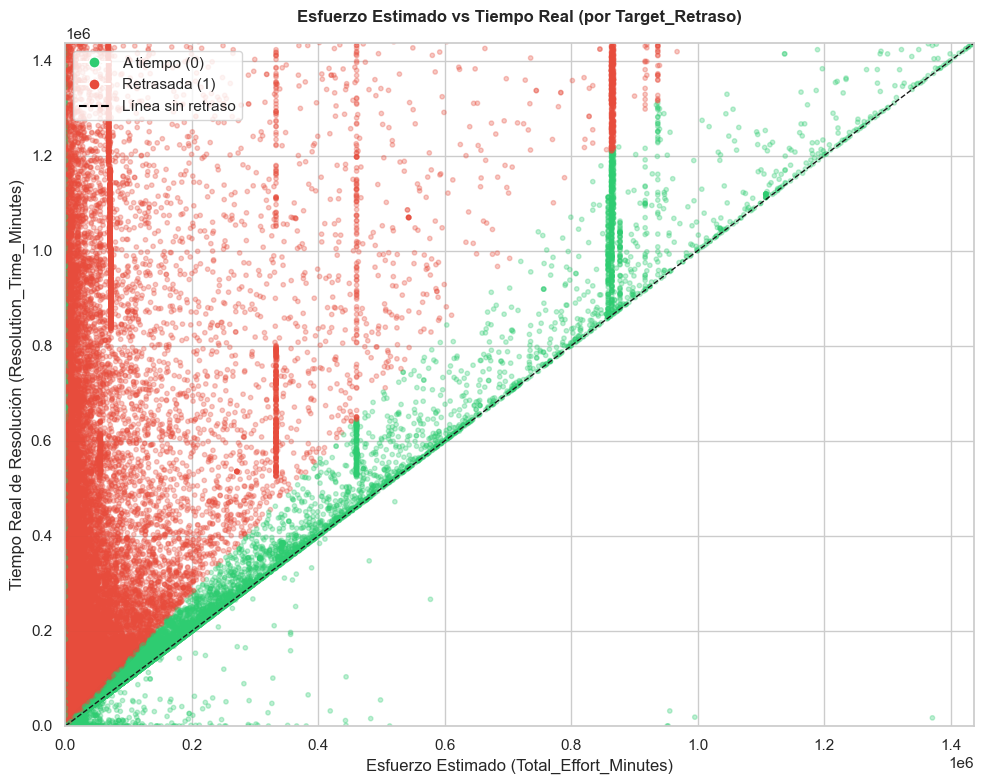

In [31]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = df['Target_Retraso'].map({0: '#2ECC71', 1: '#E74C3C'})
ax.scatter(df['Total_Effort_Minutes'], df['Resolution_Time_Minutes'],
           c=colors, alpha=0.3, s=10)

max_val = max(df['Total_Effort_Minutes'].quantile(0.95), df['Resolution_Time_Minutes'].quantile(0.95))
ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='Línea sin retraso')
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ECC71', markersize=8, label='A tiempo (0)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E74C3C', markersize=8, label='Retrasada (1)'),
    Line2D([0], [0], color='black', linestyle='--', label='Línea sin retraso')
]
ax.legend(handles=legend_elements, loc='upper left')

ax.set_xlabel('Esfuerzo Estimado (Total_Effort_Minutes)')
ax.set_ylabel('Tiempo Real de Resolución (Resolution_Time_Minutes)')
ax.set_title('Esfuerzo Estimado vs Tiempo Real (por Target_Retraso)')
plt.tight_layout()
# plt.savefig('../data/figures/scatter_esfuerzo_vs_real.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Tasa de retraso por tipo de tarea
Calculamos qué porcentaje de tareas de cada tipo acaban retrasadas.
Esta métrica ayuda a entender si ciertos tipos de tarea son más propensos a desviaciones del cronograma.

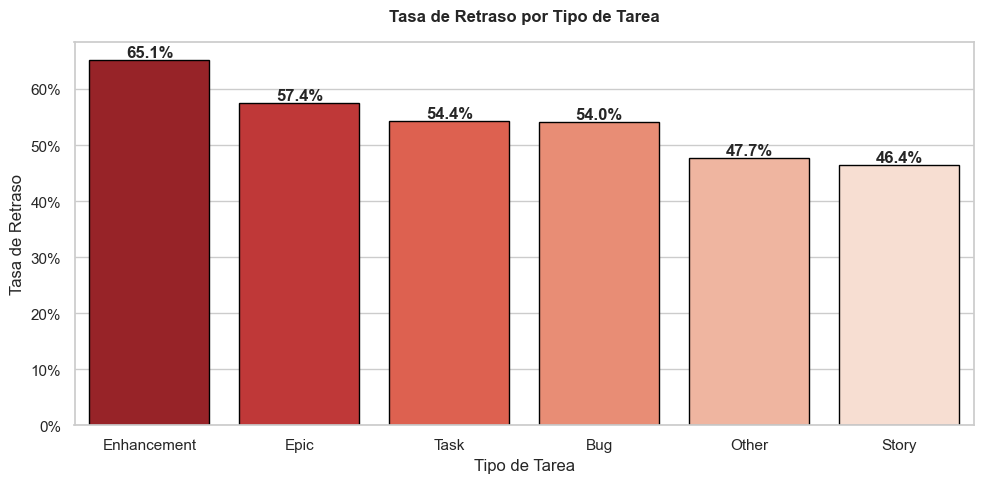

In [32]:
from matplotlib.ticker import PercentFormatter

fig, ax = plt.subplots(figsize=(10, 5))
retraso_por_tipo = df.groupby('Issue_Type')['Target_Retraso'].mean().sort_values(ascending=False)
ax = sns.barplot(x=retraso_por_tipo.index, y=retraso_por_tipo.values, hue=retraso_por_tipo.index, palette='Reds_r', legend=False, edgecolor='black')
ax.yaxis.set_major_formatter(PercentFormatter(1))
for p in ax.patches:
    ax.annotate(f"{p.get_height()*100:.1f}%",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.title('Tasa de Retraso por Tipo de Tarea')
plt.xlabel('Tipo de Tarea')
plt.ylabel('Tasa de Retraso')
plt.tight_layout()
# plt.savefig('../data/figures/tasa_retraso_por_tipo.png', dpi=300, bbox_inches='tight')
plt.show()